# Day 2｜AI 商品組合優化、品類管理與供應規劃

## 從商品績效到可執行組合策略

> **資料使用邊界：** 本 Notebook 使用固定亂數種子產生的教學虛擬資料，不是任何企業的真實營運資料。結果只能用於練習分析流程，不可宣稱為企業事實或因果效果。

### 故事情境

第二天，四家企業都遇到『選項太多』：雜草町的手作課程各有支持者；義大的套票跨越購物、飯店與樂園；盛香珍有口味、包裝與通路組合；寶島眼鏡則有鏡框、鏡片、健康服務與會員方案。主管問：哪些負責引流、哪些負責獲利、哪些值得培養、哪些需要調整？

### 今日決策問題

**如何用多指標探索商品／若你選服務型企業情境合，並在容量、庫存與企業定位限制下分配角色？**

### 學習目標

- 能建立營收、毛利、成長、波動與週轉／容量指標
- 能說明標準化對距離分群的重要性
- 能執行 KMeans 並比較群數
- 能用 PCA 觀察群集而不做因果宣稱
- 能由群集輪廓人工命名商品角色

### Colab 操作提醒

1. 在 Google Drive 建立個人副本。
2. 將對應 CSV 上傳到 Colab `/content`，或保持教材包原始相對路徑。
3. 由上到下依序執行；若 Runtime 重啟，請重新執行全部儲存格。
4. 每個程式碼儲存格後都有繁體中文說明、預期輸出與完成檢核。

> **明志科技大學 M4｜盛香珍 × 亙美質珍 專屬 Notebook**  
> 教學設計與教材製作｜恩恩統計家教  
> www.enentutor.com

#### 第一次使用 Google Colab

1. 登入 Google 帳號後，選擇「檔案 → 在雲端硬碟中儲存副本」。
2. 依頁面順序按儲存格左側播放鍵；也可按 `Shift+Enter` 執行目前儲存格。
3. 星號表示正在執行，綠色勾選表示完成；看到紅字時先讀最末一行。
4. 若執行順序混亂，選擇「執行階段 → 重新啟動工作階段並全部執行」。
5. 本 Notebook 已綁定 盛香珍 × 亙美質珍，不需修改企業名稱；Raw 失敗時才上傳同企業 CSV 到 `/content`。

### [D2-S01] 載入商品組合月資料

In [1]:
# 本格目的：載入套件並找到教學資料檔
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

# 設定繁體中文字型；Colab 缺少 Noto CJK 時才安裝，避免圖表標題出現方框
import subprocess
import sys
import matplotlib as mpl
from matplotlib import font_manager

FONT_CANDIDATES = [
    Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
    Path("C:/Windows/Fonts/msjh.ttc"),
    Path("C:/Windows/Fonts/msjhbd.ttc"),
    Path("/System/Library/Fonts/PingFang.ttc"),
]
font_path = next((path for path in FONT_CANDIDATES if path.exists()), None)
if font_path is None and "google.colab" in sys.modules:
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-noto-cjk"], check=True)
    font_manager._load_fontmanager(try_read_cache=False)
    font_path = next((path for path in FONT_CANDIDATES if path.exists()), None)

if font_path is not None:
    font_name = font_manager.FontProperties(fname=str(font_path)).get_name()
    mpl.rcParams["font.family"] = [font_name, "sans-serif"]
else:
    font_name = "Noto Sans CJK TC"
    mpl.rcParams["font.family"] = [
        "Noto Sans CJK TC", "Microsoft JhengHei", "PingFang TC", "sans-serif"
    ]
mpl.rcParams["axes.unicode_minus"] = False

# Plotly 若已安裝，同步設定預設範本的繁體中文字型；未安裝時不增加課堂錯誤
try:
    import plotly.io as pio

    pio.templates.default = "plotly_white"
    pio.templates["plotly_white"].layout.font.family = (
        "Noto Sans CJK TC, Noto Sans TC, PingFang TC, Microsoft JhengHei, sans-serif"
    )
except (ImportError, KeyError, AttributeError):
    pass
print(f"圖表中文字型：{font_name}")

# 優先從公開 GitHub Raw 讀取企業專屬資料；失敗時再依序尋找 /content 與本機相對路徑
import os

ENTERPRISE_ID = "shengxiangzhen-genmei"
ENTERPRISE_NAME = "盛香珍X亙美質珍"
ENTERPRISE_DISPLAY_NAME = "盛香珍 × 亙美質珍"
RAW_DATA_URL = "https://raw.githubusercontent.com/johnnychao/mcut-m4-business-analytics-2026-student/main/docs/resources/data/shengxiangzhen-genmei/day-2-shengxiangzhen-genmei-product-portfolio.csv"
DATA_FILENAME = "day-2-shengxiangzhen-genmei-product-portfolio.csv"
FORCE_LOCAL_DATA = os.environ.get("M4_FORCE_LOCAL_DATA") == "1"

try:
    # 正式教材 QA 可關閉遠端來源，確認企業專屬本機資料能獨立運作
    if FORCE_LOCAL_DATA:
        raise ConnectionError("M4 Notebook QA：改用本機資料備援")
    df = pd.read_csv(RAW_DATA_URL)
    data_source = RAW_DATA_URL
except Exception as remote_error:
    candidate_paths = [
        Path("/content") / DATA_FILENAME,
        Path(DATA_FILENAME),
        Path("../04_data") / ENTERPRISE_ID / DATA_FILENAME,
        Path("../../04_data") / ENTERPRISE_ID / DATA_FILENAME,
    ]
    data_path = next((path for path in candidate_paths if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            f"GitHub Raw 暫時無法讀取，而且 /content 與本機相對路徑都找不到 {DATA_FILENAME}。"
        ) from remote_error
    df = pd.read_csv(data_path)
    data_source = str(data_path)

# 企業專屬 CSV 應只有一家公司；若不一致就立即停止，避免跨企業混算
if df["company"].nunique() != 1 or str(df["company"].iloc[0]) != ENTERPRISE_NAME:
    raise ValueError(f"資料企業不符：預期 {ENTERPRISE_NAME}，實際 {df['company'].unique().tolist()}")

# 所有課堂匯出檔依企業集中，避免 16 本 Notebook 的輸出互相覆蓋
OUTPUT_DIR = Path("outputs") / ENTERPRISE_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"企業情境：{ENTERPRISE_DISPLAY_NAME}")
print(f"資料來源：{data_source}")
print(f"資料尺寸：{df.shape}")
display(df.head(3))

圖表中文字型：Microsoft JhengHei
企業情境：盛香珍 × 亙美質珍
資料來源：..\04_data\shengxiangzhen-genmei\day-2-shengxiangzhen-genmei-product-portfolio.csv
資料尺寸：(240, 16)


,month,company,offer_id,offer,category,channel,units_sold,capacity_units,price,unit_cost,repeat_rate,satisfaction,growth_rate,lead_time_days,is_service,is_synthetic
0,2025-01-01,盛香珍X亙美質珍,D2-03-01,經典小泡芙-方案1,經典小泡芙,線上,43,87,68,23,0.230,3.640,-0.051,5,0,True
1,2025-02-01,盛香珍X亙美質珍,D2-03-01,經典小泡芙-方案1,經典小泡芙,線上,47,102,68,23,0.190,3.190,-0.068,5,0,True
2,2025-03-01,盛香珍X亙美質珍,D2-03-01,經典小泡芙-方案1,經典小泡芙,線上,50,90,68,23,0.103,3.360,-0.042,7,0,True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 載入資料並確認 Colab 或教材包路徑。
- **預期輸出：** 資料尺寸與前三列。
- **完成檢核：** 資料約 960 列，且有 `is_synthetic`。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S02] 檢查資料並選定單一企業

In [2]:
# 本格目的：處理日期、缺失與企業篩選
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

assert df["is_synthetic"].astype(str).str.lower().eq("true").all()
df["month"] = pd.to_datetime(df["month"], errors="coerce")
for col in ["repeat_rate", "satisfaction"]:
    df[col] = df.groupby("company")[col].transform(lambda s: s.fillna(s.median()))

# 本 Notebook 已由網站企業卡片綁定唯一企業，不需再次選擇
company_df = df.copy()
assert company_df["company"].nunique() == 1 and not company_df.empty
print("資料筆數：", len(company_df))
print("商品／服務數：", company_df["offer_id"].nunique())
display(company_df.head(3))

資料筆數： 240
商品／服務數： 20


,month,company,offer_id,offer,category,channel,units_sold,capacity_units,price,unit_cost,repeat_rate,satisfaction,growth_rate,lead_time_days,is_service,is_synthetic
0,2025-01-01,盛香珍X亙美質珍,D2-03-01,經典小泡芙-方案1,經典小泡芙,線上,43,87,68,23,0.230,3.640,-0.051,5,0,True
1,2025-02-01,盛香珍X亙美質珍,D2-03-01,經典小泡芙-方案1,經典小泡芙,線上,47,102,68,23,0.190,3.190,-0.068,5,0,True
2,2025-03-01,盛香珍X亙美質珍,D2-03-01,經典小泡芙-方案1,經典小泡芙,線上,50,90,68,23,0.103,3.360,-0.042,7,0,True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 確認虛擬標記、補足兩個教學缺失欄，並將資料限制在一家企業。
- **預期輸出：** 240 列月資料與 20 個商品／服務。
- **完成檢核：** 企業唯一值為 1，offer_id 唯一值為 20。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S03] 建立商品／服務 KPI 輪廓

In [3]:
# 本格目的：把月資料彙總成每個商品／服務的一列決策輪廓
company_df["revenue"] = company_df["units_sold"] * company_df["price"]
company_df["gross_profit"] = company_df["units_sold"] * (company_df["price"] - company_df["unit_cost"])

portfolio = company_df.groupby(["offer_id", "offer", "category"], as_index=False).agg(
    units_sold=("units_sold", "sum"),
    capacity_units=("capacity_units", "sum"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    repeat_rate=("repeat_rate", "mean"),
    satisfaction=("satisfaction", "mean"),
    growth_rate=("growth_rate", "mean"),
    lead_time_days=("lead_time_days", "mean"),
    monthly_std=("units_sold", "std"),
)
portfolio["gross_margin_rate"] = portfolio["gross_profit"] / portfolio["revenue"]
portfolio["resource_utilization"] = portfolio["units_sold"] / portfolio["capacity_units"]
portfolio["demand_volatility"] = portfolio["monthly_std"] / portfolio["units_sold"].div(12)
display(portfolio.sort_values("gross_profit", ascending=False).head(10).round(3))

,offer_id,offer,category,units_sold,capacity_units,revenue,gross_profit,repeat_rate,satisfaction,growth_rate,lead_time_days,monthly_std,gross_margin_rate,resource_utilization,demand_volatility
4,D2-03-05,經典小泡芙-方案2,經典小泡芙,1099,1322,120890,80227,0.448,4.197,0.085,20.500,11.735,0.664,0.831,0.128
9,D2-03-10,限定風味小泡芙-方案3,限定風味小泡芙,1202,1436,132220,79332,0.446,4.081,0.081,20.833,12.641,0.600,0.837,0.126
14,D2-03-15,分享派對包-方案4,分享派對包,1153,1399,126830,68027,0.431,4.110,0.093,21.250,11.221,0.536,0.824,0.117
8,D2-03-09,經典小泡芙-方案3,經典小泡芙,937,1237,93700,61842,0.364,3.935,0.036,16.750,11.728,0.660,0.757,0.150
19,D2-03-20,跨界聯名禮盒-方案5,跨界聯名禮盒,1145,1387,125950,60685,0.458,4.042,0.069,21.250,9.249,0.482,0.826,0.097
18,D2-03-19,分享派對包-方案5,分享派對包,1005,1313,100500,54270,0.343,3.939,0.024,16.583,9.536,0.540,0.765,0.114
13,D2-03-14,限定風味小泡芙-方案4,限定風味小泡芙,837,1105,83700,50220,0.376,3.987,0.054,17.083,12.707,0.600,0.757,0.182
12,D2-03-13,經典小泡芙-方案4,經典小泡芙,761,1110,67729,44899,0.294,3.734,0.007,12.833,7.280,0.663,0.686,0.115
17,D2-03-18,限定風味小泡芙-方案5,限定風味小泡芙,728,1037,64792,38584,0.309,3.808,0.003,13.500,8.595,0.596,0.702,0.142
3,D2-03-04,跨界聯名禮盒-方案1,跨界聯名禮盒,759,1003,75900,36432,0.366,3.868,0.044,16.750,9.166,0.480,0.757,0.145


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 先加總分子、分母後再計算毛利率與容量利用率，避免直接平均月比率。
- **預期輸出：** 20 列商品／服務 KPI 表。
- **完成檢核：** 營收與毛利為金額；比率大致在 0 到 1 之間。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S04] 繪製成長－毛利績效矩陣

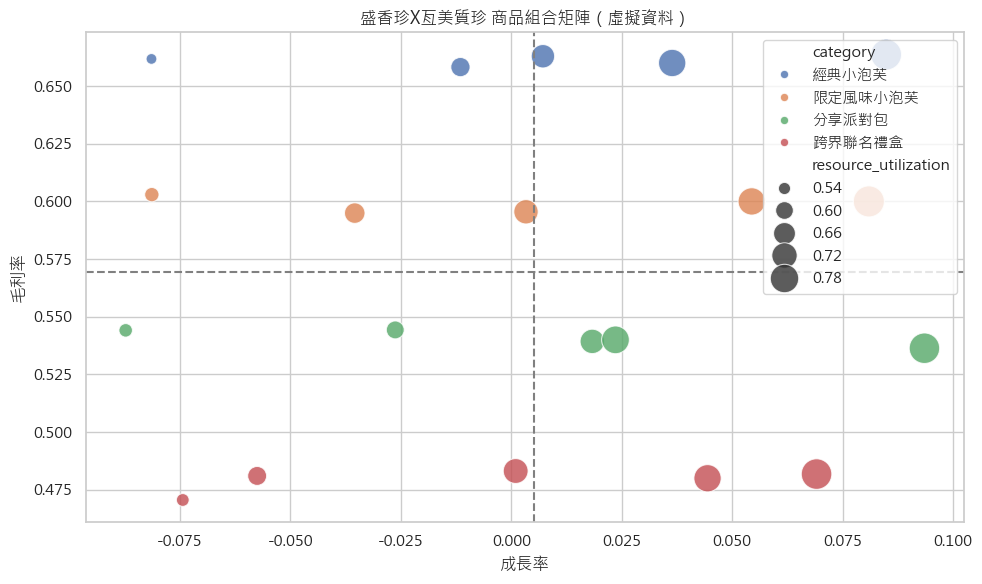

In [4]:
# 本格目的：用毛利、成長、利用率同時觀察組合位置
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=portfolio, x="growth_rate", y="gross_margin_rate",
    size="resource_utilization", hue="category", sizes=(60, 500), alpha=0.8,
)
plt.axhline(portfolio["gross_margin_rate"].median(), color="gray", linestyle="--")
plt.axvline(portfolio["growth_rate"].median(), color="gray", linestyle="--")
plt.title(f"{ENTERPRISE_NAME} 商品組合矩陣（虛擬資料）")
plt.xlabel("成長率")
plt.ylabel("毛利率")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以成長與毛利定位商品，再用氣泡大小表示資源利用。
- **預期輸出：** 一張四象限氣泡圖。
- **完成檢核：** 圖表只描述目前虛擬績效，不直接等同商品角色。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S05] 標準化六個分群特徵

In [5]:
# 本格目的：讓不同單位指標在距離計算中有相近權重
feature_cols = [
    "gross_margin_rate", "growth_rate", "resource_utilization",
    "repeat_rate", "satisfaction", "demand_volatility",
]
feature_matrix = portfolio[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(portfolio[feature_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
display(scaled_df.describe().round(2))

,gross_margin_rate,growth_rate,resource_utilization,repeat_rate,satisfaction,demand_volatility
count,20.000,20.000,20.000,20.000,20.000,20.000
mean,0.000,-0.000,0.000,0.000,0.000,0.000
std,1.030,1.030,1.030,1.030,1.030,1.030
min,-1.470,-1.570,-1.620,-1.430,-1.460,-1.540
25%,-0.690,-0.770,-0.780,-0.720,-0.780,-0.900
50%,-0.010,0.040,0.110,-0.020,-0.190,0.000
75%,0.690,0.760,0.680,0.690,0.770,0.700
max,1.380,1.570,1.460,1.590,1.830,2.190


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 將毛利率、成長、利用率等不同尺度指標轉為平均 0、標準差約 1。
- **預期輸出：** 標準化後描述統計。
- **完成檢核：** 各特徵平均值接近 0；沒有缺失或無限值。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S06] 比較 k=3、4、5 的群數

,k,inertia,silhouette
0,3,34.599,0.340
1,4,28.792,0.251
2,5,22.545,0.277


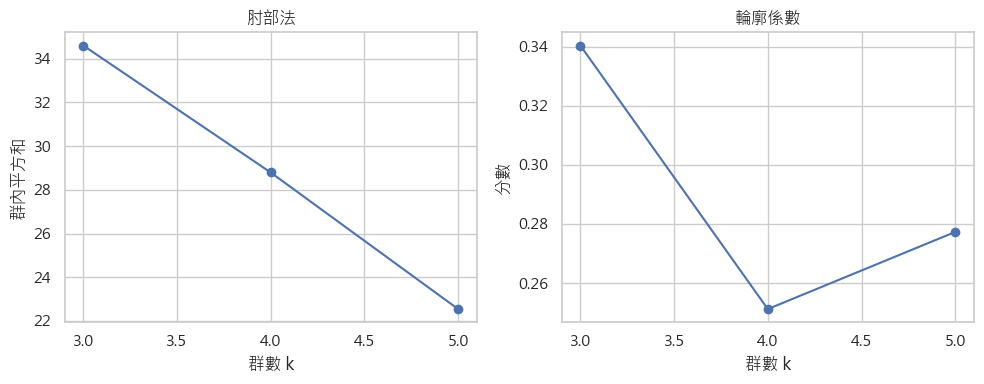

In [6]:
# 本格目的：用 inertia、silhouette 與商業可解釋性選擇群數
score_rows = []
for k in range(3, 6):
    candidate = KMeans(n_clusters=k, random_state=20260714, n_init=10)
    labels = candidate.fit_predict(X_scaled)
    score_rows.append({"k": k, "inertia": candidate.inertia_, "silhouette": silhouette_score(X_scaled, labels)})
k_scores = pd.DataFrame(score_rows)
display(k_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_scores["k"], k_scores["inertia"], marker="o")
axes[0].set(title="肘部法", xlabel="群數 k", ylabel="群內平方和")
axes[1].plot(k_scores["k"], k_scores["silhouette"], marker="o")
axes[1].set(title="輪廓係數", xlabel="群數 k", ylabel="分數")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 比較 k=3、4、5；inertia 越低、silhouette 越高通常較好，但仍需能被企業解釋。
- **預期輸出：** 群數比較表與兩張折線。
- **完成檢核：** 不因商品角色有四種就強迫 k=4。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S07] 建立 KMeans 並解讀群集輪廓

本次採用 k=3；群號沒有優劣順序。


,gross_margin_rate,growth_rate,resource_utilization,repeat_rate,satisfaction,demand_volatility
cluster,,,,,,
0,0.570,0.082,0.830,0.445,4.108,0.117
1,0.570,-0.057,0.583,0.198,3.538,0.219
2,0.570,0.024,0.730,0.331,3.837,0.149


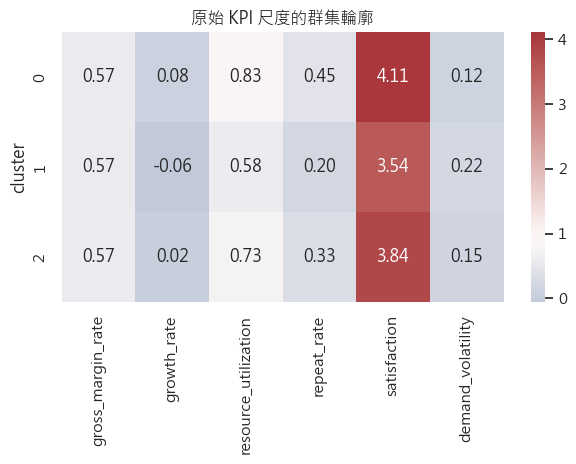

In [7]:
# 本格目的：使用得分較佳的群數建立可重現群集
BEST_K = int(k_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
kmeans = KMeans(n_clusters=BEST_K, random_state=20260714, n_init=10)
portfolio["cluster"] = kmeans.fit_predict(X_scaled)
print(f"本次採用 k={BEST_K}；群號沒有優劣順序。")

cluster_profile = portfolio.groupby("cluster")[feature_cols].mean().round(3)
display(cluster_profile)
sns.heatmap(cluster_profile, cmap="vlag", center=portfolio[feature_cols].mean().mean(), annot=True, fmt=".2f")
plt.title("原始 KPI 尺度的群集輪廓")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以固定 seed 建立群集，回到原始 KPI 平均值查看輪廓。
- **預期輸出：** 群集輪廓表與熱圖。
- **完成檢核：** cluster 0 只是一個編號，不是第一名。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S08] 用 PCA 呈現群集與變數方向

前兩主成分解釋變異： [0.784 0.171]


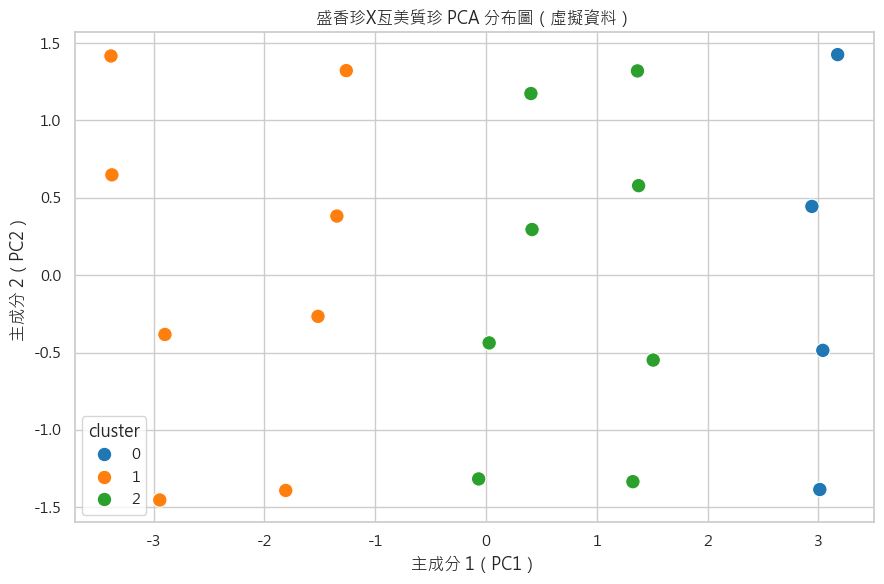

,PC1,PC2
gross_margin_rate,0.011,0.984
growth_rate,0.453,0.046
resource_utilization,0.458,-0.029
repeat_rate,0.458,0.002
satisfaction,0.451,0.088
demand_volatility,-0.415,0.145


In [8]:
# 本格目的：把六個標準化指標壓縮到二維，方便觀察相似性
pca = PCA(n_components=2, random_state=20260714)
scores = pca.fit_transform(X_scaled)
portfolio["PC1"] = scores[:, 0]
portfolio["PC2"] = scores[:, 1]
print("前兩主成分解釋變異：", np.round(pca.explained_variance_ratio_, 3))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=portfolio, x="PC1", y="PC2", hue="cluster", palette="tab10", s=110)
plt.title(f"{ENTERPRISE_NAME} PCA 分布圖（虛擬資料）")
plt.xlabel("主成分 1（PC1）")
plt.ylabel("主成分 2（PC2）")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=["PC1", "PC2"])
display(loadings.round(3))

#### 程式碼說明（繁體中文）

- **這段做了什麼：** PCA 只用於壓縮與視覺探索，loadings 顯示哪些指標對主成分方向貢獻較大。
- **預期輸出：** PCA 散點圖、解釋變異與 loadings。
- **完成檢核：** 不得把 PCA 解釋變異當成模型準確率。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S09] 人工命名角色並加入供應風險

In [9]:
# 本格目的：把分群輪廓翻譯成可討論的商品角色
overall = portfolio[feature_cols].median()

def suggest_role(row):
    if row["growth_rate"] > overall["growth_rate"] and row["gross_margin_rate"] > overall["gross_margin_rate"]:
        return "成長／獲利候選"
    if row["resource_utilization"] > overall["resource_utilization"] and row["gross_margin_rate"] <= overall["gross_margin_rate"]:
        return "引流／容量管理候選"
    if row["repeat_rate"] > overall["repeat_rate"]:
        return "會員／加購候選"
    return "調整／限量測試候選"

portfolio["suggested_role"] = portfolio.apply(suggest_role, axis=1)
portfolio["supply_risk"] = np.where(
    (portfolio["resource_utilization"] > 0.85) & (portfolio["lead_time_days"] > portfolio["lead_time_days"].median()),
    "高：容量緊且前置期長", "一般",
)
display(portfolio[["offer", "cluster", "suggested_role", "gross_margin_rate", "growth_rate", "resource_utilization", "supply_risk"]].round(3))

,offer,cluster,suggested_role,gross_margin_rate,growth_rate,resource_utilization,supply_risk
0,經典小泡芙-方案1,1,調整／限量測試候選,0.662,-0.081,0.528,一般
1,限定風味小泡芙-方案1,1,調整／限量測試候選,0.595,-0.035,0.639,一般
2,分享派對包-方案1,2,引流／容量管理候選,0.539,0.018,0.702,一般
3,跨界聯名禮盒-方案1,2,引流／容量管理候選,0.480,0.044,0.757,一般
4,經典小泡芙-方案2,0,成長／獲利候選,0.664,0.085,0.831,一般
5,限定風味小泡芙-方案2,1,調整／限量測試候選,0.603,-0.081,0.561,一般
6,分享派對包-方案2,1,調整／限量測試候選,0.544,-0.026,0.603,一般
7,跨界聯名禮盒-方案2,2,引流／容量管理候選,0.483,0.001,0.710,一般
8,經典小泡芙-方案3,2,成長／獲利候選,0.660,0.036,0.757,一般
9,限定風味小泡芙-方案3,0,成長／獲利候選,0.600,0.081,0.837,一般


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 用透明規則產生角色候選，再要求個人依企業定位修改；這不是演算法標準答案。
- **預期輸出：** 每個商品的群號、候選角色與供應風險。
- **完成檢核：** 個人能引用至少一個 KPI 說明是否接受或修改角色。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D2-S10] 整理商品組合成果草稿與繳交前檢核

In [10]:
# 本格目的：保留可追溯指標，形成後續定價與上市課程輸入
portfolio["recommended_action"] = np.select(
    [
        portfolio["suggested_role"].eq("成長／獲利候選"),
        portfolio["suggested_role"].eq("引流／容量管理候選"),
        portfolio["suggested_role"].eq("會員／加購候選"),
    ],
    ["培養並做容量測試", "維持但設容量護欄", "設計加購／會員組合"],
    default="調整或限量驗證",
)
output_cols = [
    "offer_id", "offer", "cluster", "suggested_role", "recommended_action",
    "revenue", "gross_profit", "gross_margin_rate", "growth_rate",
    "resource_utilization", "repeat_rate", "supply_risk",
]
decision_output = portfolio[output_cols].sort_values(["cluster", "gross_profit"], ascending=[True, False])
display(decision_output.round(3))
decision_output.to_csv(OUTPUT_DIR / "Day2_商品組合決策表.csv", index=False, encoding="utf-8-sig")

,offer_id,offer,cluster,suggested_role,recommended_action,revenue,gross_profit,gross_margin_rate,growth_rate,resource_utilization,repeat_rate,supply_risk
4,D2-03-05,經典小泡芙-方案2,0,成長／獲利候選,培養並做容量測試,120890,80227,0.664,0.085,0.831,0.448,一般
9,D2-03-10,限定風味小泡芙-方案3,0,成長／獲利候選,培養並做容量測試,132220,79332,0.600,0.081,0.837,0.446,一般
14,D2-03-15,分享派對包-方案4,0,引流／容量管理候選,維持但設容量護欄,126830,68027,0.536,0.093,0.824,0.431,一般
19,D2-03-20,跨界聯名禮盒-方案5,0,引流／容量管理候選,維持但設容量護欄,125950,60685,0.482,0.069,0.826,0.458,一般
16,D2-03-17,經典小泡芙-方案5,1,調整／限量測試候選,調整或限量驗證,53246,35048,0.658,-0.012,0.621,0.240,一般
1,D2-03-02,限定風味小泡芙-方案1,1,調整／限量測試候選,調整或限量驗證,50955,30315,0.595,-0.035,0.639,0.240,一般
6,D2-03-07,分享派對包-方案2,1,調整／限量測試候選,調整或限量驗證,47795,26015,0.544,-0.026,0.603,0.232,一般
11,D2-03-12,跨界聯名禮盒-方案3,1,調整／限量測試候選,調整或限量驗證,47242,22724,0.481,-0.057,0.616,0.220,一般
0,D2-03-01,經典小泡芙-方案1,1,調整／限量測試候選,調整或限量驗證,30464,20160,0.662,-0.081,0.528,0.159,一般
5,D2-03-06,限定風味小泡芙-方案2,1,調整／限量測試候選,調整或限量驗證,30396,18327,0.603,-0.081,0.561,0.164,一般


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 把分群、角色候選、KPI 與供應風險放在同一份可交接決策表。
- **預期輸出：** 20 列決策表與輸出 CSV。
- **完成檢核：** 每項行動均可回指 KPI，且仍保留人工修改空間。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

## 當日學習驗收

正式作答請由課程網站進入當日 Google Form。本區只供你先確認題意與個人繳交內容，請勿在 Notebook 尋找或記錄正確選項。

### 10 題選擇題

#### 第 1 題｜基礎｜容易

KMeans 在本課屬於哪一類方法？

- A. 有標籤的監督式分類
- B. 無標籤的非監督式分群
- C. 價格因果推論
- D. 時間序列預測

#### 第 2 題｜基礎｜容易

商品全年毛利額的基本計算是哪一項？

- A. 銷量×（售價－單位成本）
- B. 售價＋單位成本
- C. 營收÷容量
- D. 滿意度×成長率

#### 第 3 題｜基礎｜容易

KMeans 前進行標準化的主要原因是什麼？

- A. 保證每群一樣大
- B. 避免大尺度變數主導距離
- C. 自動產生商品角色
- D. 把所有值限制在 0 到 1

#### 第 4 題｜情境應用｜容易

服務型方案沒有實體庫存時，最適合優先採用哪個資源指標？

- A. 時段、席次或房晚容量利用率
- B. 檔案大小
- C. 商品條碼長度
- D. 圖片像素

#### 第 5 題｜情境應用｜容易

主管說 cluster 0 是第一名商品群，分析師應如何回應？

- A. 同意，0 代表冠軍
- B. 說明群號只是標籤，需看 KPI 輪廓後命名
- C. 把 0 改成 100
- D. 刪除其他群

#### 第 6 題｜情境應用｜容易

選擇 k 時最完整的做法是哪一項？

- A. 角色有四種，所以固定 k=4
- B. 永遠選 inertia 最小者
- C. 結合 inertia、silhouette、群大小與商業可解釋性
- D. 用最高毛利商品數當 k

#### 第 7 題｜情境應用｜中等

某服務利用率 0.90、前置期高於中位數，最合理的行動是什麼？

- A. 立即全面加碼，不設上限
- B. 列入容量風險，先設定預警、承接量與停止條件
- C. 因為熱門就忽略滿意度
- D. 把利用率手動改成 0.80

#### 第 8 題｜輸出判讀｜中等

k_scores 為 k=3 silhouette 0.344、k=4 0.288、k=5 0.266。最保守結論是什麼？

- A. 先檢查 k=3 輪廓，但仍需商業與穩定性驗證
- B. 分群準確率只有 34.4%
- C. 永遠使用三群
- D. k=5 inertia 最低所以必定最好

#### 第 9 題｜輸出判讀｜中等

群2 的毛利率 0.600、成長 -0.078、回購 0.168、波動 0.250，哪個名稱較合宜？

- A. 全面最差並立即淘汰
- B. 高毛利率但低成長／高波動的調整驗證候選
- C. 唯一明星群
- D. 已證明價格造成需求下降

#### 第 10 題｜輸出判讀｜整合

PCA 輸出 PC1=0.732、PC2=0.179，且 PC2 毛利率 loading=0.938，正確解讀是什麼？

- A. 模型預測準確率 91.1%
- B. 前兩軸保留約 91.1% 特徵變異，PC2 主要反映毛利率方向
- C. PC2 證明毛利造成群集
- D. 所有 PC2 正值商品都要加碼

## 個人 Colab 實作｜17:20–18:40

使用你在網站選擇的企業專屬 Notebook，先 Restart and Run All，不必從零重寫 KMeans 或 PCA。在 `BEST_K` 或一項資源限制中擇一調整，比較調整前後的群集輪廓與角色建議。選一項商品／服務，引用兩個 KPI，提出一個角色與一項資源配置，再用 120 字內說明理由與限制。

### 個人繳交內容

- 可 Restart and Run All 的企業專屬 .ipynb
- Notebook 自動產生的群集輪廓或 PCA 圖
- 一項商品／服務的角色與資源配置
- 120 字內決策摘要

### 繳交前檢查

- 已從「執行階段」重新啟動並全部執行，所有儲存格無紅字。
- Notebook、CSV、圖表與摘要都對應網站所選的同一企業情境。
- 已在 Google Form 貼上可檢視的 Colab 分享網址與自己的決策摘要。
- 摘要有引用核心輸出，也有說明虛擬資料限制與下一步驗證。